In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *

## 1 COLOR

In [3]:
savepath_TS_1_color = "../results/TimeSeries/2D"
create_folder(savepath_TS_1_color)

## <b> FIGURE 1 </b>

$P_0 = 100$ (seeds)  
$p_0 = 1.0$ (initial probability)  
$L = 1000$  
$k = 10^{-5}$  
$N_T = 200$


In [4]:
num_colors = 1
k = 1.0e-05
rho_val = 1.0
#path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_2/L_1000/NT_constant/NT_200/k_{k:.1e}/rho_{rho_val:.4e}/network/"
path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_2/L_1000/NT_constant/NT_200/k_{k:.1e}/rho_{rho_val:.4e}/network/"
filename = list_npz_files(path)[0]
print(filename)
plot_bond_network(
    path+filename,
    num_colors=num_colors,
    savepath=savepath_TS_1_color + f"/Network.pdf",
    dpi=600,
    min_density=1,
    color_map=None,          # dict[int,str] opcional: {valor_ativo: cor}
    linewidth=0.25,
    figsize=(8, 10),
    show_legend=True
)
    

P0_0.10_p0_1.00_seed_1579532130.npy


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

## <b> FIGURE 2 </b>

Network $2000$ x $2000$ -> $L$ x $L$  
$L = 2000$  
$k = 10^{-4}$  
$N_T = 200$  
$P_0 = 100$ (seeds)  

(a)  
$p_0 = [0.4, 0.8, 1.0]$ (initial probability)  

(b)  
$p_0 = [0.3, 0.7, 1.0]$ (initial probability)  

In [3]:
L = 2000
k = 1.0e-04
Nt = 200
dim = 2
rho = 1.0
prop = "Pt"
num_colors = 1

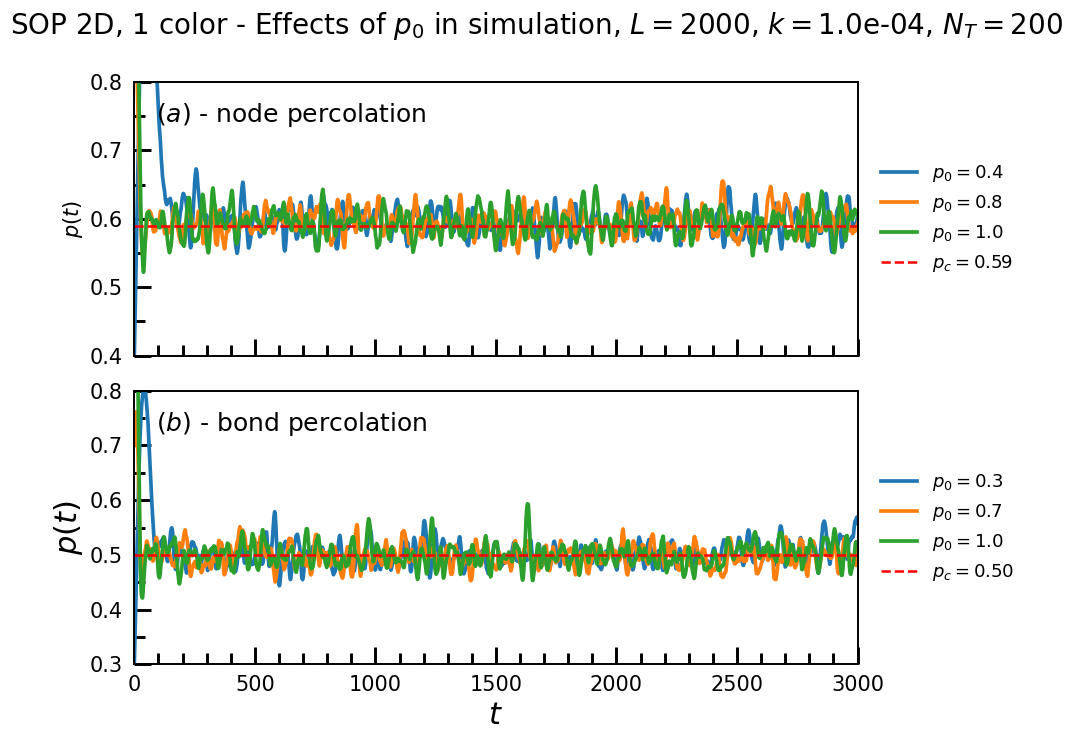

In [4]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), sharex=True)


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 15
fontsize_legend = 13
fontsize_labels = 22
thickness = 1.4

p_0_node = [0.4, 0.8, 1.0]
seeds_name_node = [480395598, 624311778 , 1501065791] #lab
#seeds_name_node = [1567861503, 578991113 , 1273693407] #home

p_0_bond = [0.3, 0.7, 1.0]
seeds_name_bond = [1089768116, 157234428, 393055465] #lab
#seeds_name_bond = [417464870, 642617456, 76918351] #home

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', 'd62728']

for i in range(len(seeds_name_node)):
    prop_node_names = data_single_sample('node', num_colors, dim, L, Nt, k, rho, p_0_node[i], seeds_name_node[i])        
    t, pt = prop_node_names["t"], prop_node_names["p_1"]
    axs[0].plot(t, pt, lw=1.9*thickness, label=f'$p_0 = {p_0_node[i]}$', color=colors[i])


for i in range(len(seeds_name_bond)):
    type_perc = 'bond'
    prop_bond_names = data_single_sample('bond', num_colors, dim, L, Nt, k, rho, p_0_bond[i], seeds_name_bond[i])        
    t, pt = prop_bond_names["t"], prop_bond_names["p_1"]
    axs[1].plot(t, pt, lw=1.9*thickness, label=f'$p_0 = {p_0_bond[i]}$', color=colors[i])

xmax =  3000

axs[0].hlines(y=0.59, xmin=0, xmax=xmax, linestyles="--", color='r', lw=1.8, label="$p_c = 0.59$")
axs[1].hlines(y=0.50, xmin=0, xmax=xmax, linestyles="--", color='r', lw=1.8, label="$p_c = 0.50$")

for ax in axs:
    ax.set_xlim([0, xmax])
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())

    # Y: major ticks a cada 1 unidade
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))

    # Opcional: ajuste visual dos ticks
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=12, width=1.5*thickness, pad = 8)
    ax.tick_params(axis='x',   which='minor', direction='in', length=8, width=1.5*thickness)   # only x minor
    ax.tick_params(axis='y',   which='minor', direction='in', length=8, width=1.5*thickness)   # only x minor
    
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
              framealpha=0.0, fontsize=fontsize_legend)
    
    ax.set_ylabel("$p(t)$",fontsize=fontsize_labels)

axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes,
            ha="left", va="top", fontsize=18)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes,
            ha="left", va="top", fontsize=18)



axs[0].set_ylim([0.4, 0.8])
axs[1].set_ylim([0.3, 0.8])


#axs[0].legend(framealpha=0.0,fontsize=fontsize_ticks)

axs[0].set_ylabel("$p(t)$",fontsize=fontsize_ticks)
#axs[0].tick_params(axis='both', labelsize=fontsize_ticks, width=thickness, length = 4.0, direction='in')

#axs[1].set_title("Bond Percolation")
#axs[1].legend(framealpha=0.0,fontsize=fontsize_ticks)
axs[1].set_xlabel("$t$",fontsize=fontsize_labels)


plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.suptitle(f"SOP 2D, 1 color - Effects of $p_0$ in simulation, $L = {L}$, $k = ${k:.1e}, $N_T = {Nt}$", fontsize=20, y=1.05)
plt.show()

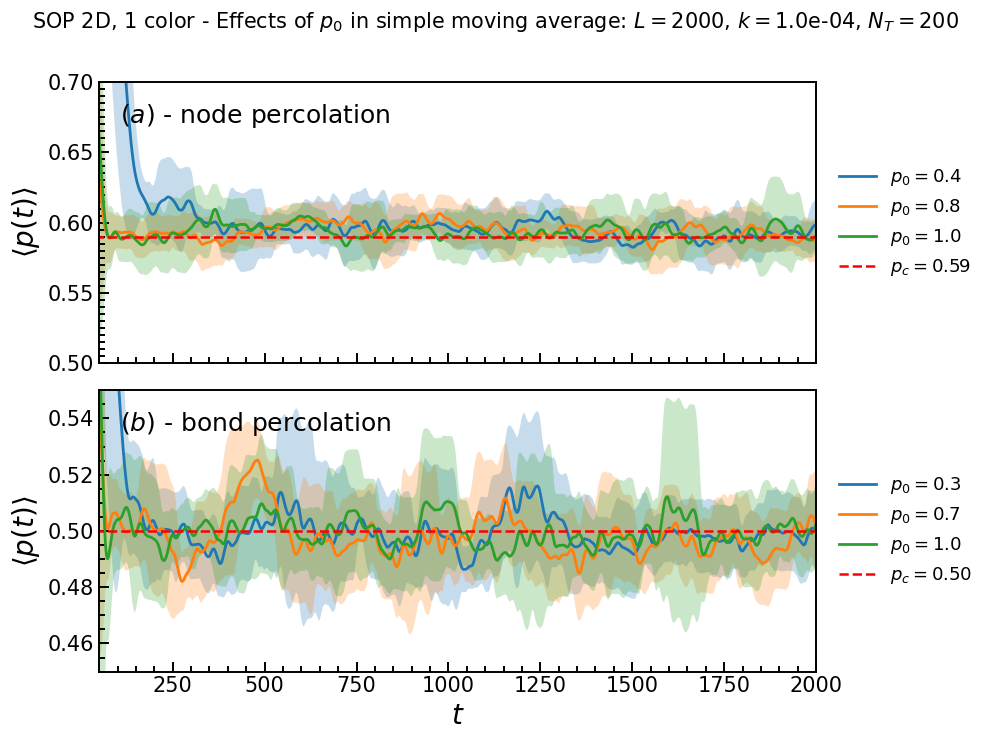

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ---------- janela deslizante ----------
def rolling_mean_std(t, y, window: int):
    """
    Retorna (t_centrado, media, desvio_padrao) para uma janela deslizante de tamanho 'window'.
    A série resultante fica centrada na janela.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")

    c = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))

    mean = (c[window:] - c[:-window]) / window
    var = (c2[window:] - c2[:-window]) / window - mean**2
    std = np.sqrt(np.clip(var, 0, None))

    # centraliza no tempo (para janela par funciona como 'centered' padrão)
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_legend = 13
fontsize_labels = 20
fontsize_ticks = 15
thickness = 1.4

p_0_node = [0.4, 0.8, 1.0]
p_0_node = [0.4, 0.8, 1.0]
seeds_name_node = [480395598, 624311778 , 1501065791] #lab


p_0_bond = [0.3, 0.7, 1.0]
seeds_name_bond = [1089768116, 157234428, 393055465] #lab

# p0 fixo
window = 100  # range da janela
rho = 1.0

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), sharex=True)

# --------- NODE ---------
for i, seed in enumerate(seeds_name_node):
    prop = data_single_sample('node', num_colors, dim, L, Nt, k, rho, p_0_node[i], seed)
    t, pt = prop["t"], prop["p_1"]

    # média e desvio por janela
    tc, mu, sd = rolling_mean_std(t, pt, window)

    # (opcional) trace a série original fraquinha atrás:
    # axs[0].plot(t, pt, lw=1.0, alpha=0.25, color=colors[i])

    axs[0].plot(tc, mu, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_node[i]}$')
    axs[0].fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[i], linewidth=0)

# --------- BOND ---------
for i, seed in enumerate(seeds_name_bond):
    prop = data_single_sample('bond', num_colors, dim, L, Nt, k, rho, p_0_bond[i], seed)
    t, pt = prop["t"], prop["p_1"]

    tc, mu, sd = rolling_mean_std(t, pt, window)

    # axs[1].plot(t, pt, lw=1.0, alpha=0.25, color=colors[i])  # opcional
    axs[1].plot(tc, mu, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_bond[i]}$')
    axs[1].fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[i], linewidth=0)

axs[0].hlines(y=0.59, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8, label="$p_c = 0.59$")
axs[1].hlines(y=0.50, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8, label="$p_c = 0.50$")

# ---------- estética ----------
for ax in axs:
    ax.set_xlim([float(tc[0]), 2000])
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=7, width=thickness)
    ax.tick_params(axis='x',   which='minor', direction='in', length=4, width=thickness)
    ax.tick_params(axis='y',   which='minor', direction='in', length=4, width=thickness)

    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
              framealpha=0.0, fontsize=fontsize_legend)
    ax.set_ylabel(r"$\langle p(t) \rangle$", fontsize=fontsize_labels)



axs[0].yaxis.set_major_locator(MultipleLocator(0.05))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.005))

axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes, ha="left", va="top", fontsize=18)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes, ha="left", va="top", fontsize=18)

axs[0].set_ylim([0.5,0.7])
axs[1].set_ylim([0.45,0.55])

axs[1].yaxis.set_major_locator(MultipleLocator(0.02))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.005))


axs[1].set_xlabel("$t$", fontsize=fontsize_labels)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.suptitle(f"SOP 2D, 1 color - Effects of $p_0$ in simple moving average: $L = {L}$, $k = ${k:.1e}, $N_T = {Nt}$", fontsize=15, y=1.05)
#plt.savefig(savepath_TS_1_color + "/rolling_mean_pt_2D_1color.pdf")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ---------- janela deslizante ----------
def rolling_mean_std(t, y, window: int):
    """
    Retorna (t_centrado, media, desvio_padrao) para uma janela deslizante de tamanho 'window'.
    A série resultante fica centrada na janela.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")

    c = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))

    mean = (c[window:] - c[:-window]) / window
    var = (c2[window:] - c2[:-window]) / window - mean**2
    std = np.sqrt(np.clip(var, 0, None))

    # centraliza no tempo
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 16
thickness = 1.4

p_0_node = [0.4, 0.8, 1.0]
seeds_name_node = [1819163204, 748540170 , 450131217]  # lab

p_0_bond = [0.3, 0.7, 1.0]
seeds_name_bond = [847039001, 971456870, 1767333482]  # lab

window = 100
rho = 1.0

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 7), sharex=True)

# --------- NODE: plota sigma_p(t) ---------
for i, seed in enumerate(seeds_name_node):
    prop = data_single_sample('node', num_colors, dim, L, Nt, k, rho, p_0_node[i], seed)
    t, pt = prop["t"], prop["p_1"]

    tc, mu, sd = rolling_mean_std(t, pt, window)  # mu não usado aqui
    axs[0].plot(tc, sd, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_node[i]}$')

# --------- BOND: plota sigma_p(t) ---------
for i, seed in enumerate(seeds_name_bond):
    prop = data_single_sample('bond', num_colors, dim, L, Nt, k, rho, p_0_bond[i], seed)
    t, pt = prop["t"], prop["p_1"]

    tc, mu, sd = rolling_mean_std(t, pt, window)
    axs[1].plot(tc, sd, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_bond[i]}$')

from matplotlib.ticker import AutoMinorLocator, MaxNLocator, FormatStrFormatter
# ---------- estética ----------
for ax in axs:
    ax.set_xlim([float(tc[0]), 2000])

    # deixa o Matplotlib escolher ~6 ticks "bons" e mostra os valores
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))      # 5–6 ticks
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # duas casas
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))       # 1 minor entre majors

    # opcional: garante que 0 fica visível e dá margem
    ax.set_ylim(bottom=0)          # ou: ax.margins(y=0.05)

    for spine in ax.spines.values():
        spine.set_linewidth(thickness)

    ax.tick_params(axis='both', which='major', direction='in',
                   labelsize=fontsize_ticks, length=7, width=thickness)
    ax.tick_params(axis='x', which='minor', direction='in', length=4, width=thickness)
    ax.tick_params(axis='y', which='minor', direction='in', length=4, width=thickness)

# linhas-guia (opcionais; ajuste valores se fizer sentido para sigma)
# axs[0].hlines(y=0.06, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8)
# axs[1].hlines(y=0.05, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8)

axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes, ha="left", va="top", fontsize=18)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes, ha="left", va="top", fontsize=18)

axs[0].set_ylabel(r"$\sigma_p(t)$", fontsize=fontsize_ticks)
axs[1].set_xlabel("$t$", fontsize=fontsize_ticks)
axs[1].set_ylabel(r"$\sigma_p(t)$", fontsize=fontsize_ticks)

axs[0].legend(framealpha=0.0, fontsize=fontsize_ticks)
axs[1].legend(framealpha=0.0, fontsize=fontsize_ticks)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig(savepath_TS + "/rolling_mean_std_2D_1color.pdf")
plt.show()


In [ ]:
type_perc = 'bond'
num_colors = 1
dim = 2
L= 2000
Nt = 200
k = 1.0e-04 
rho = 1.0
p0 = 1.0
seed = 308536418

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 7), sharex=True)


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

# --- Node Percolation ---
#type_percolation_node = "node"


p0 = 1.0
k_values = [1.0e-05, 1.0e-05, 1.0e-05]
Nt_values = [300, 200, 100]
seeds_name = [1897561577, 1356373728, 1918868487]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(len(seeds_name)):
    prop_node_names = data_single_sample('bond', num_colors, dim, L, Nt_values[i], k_values[i], rho, p0, seeds_name[i])        
    t, nt = prop_node_names["t"], prop_node_names["N_1"]
    data_filter = nt[400:]
    nt_mean = np.mean(data_filter)
    
    ax.plot(t, nt, lw=1.9*thickness, label=f'$N_t = {Nt_values[i]}$, $k =$ {k_values[i]:.1e}, $\\langle N(t) \\rangle = {nt_mean:.0f}$, $t_p = {max(t)}$', color=colors[i])
    ax.axhline(y=nt_mean, xmin=min(t), xmax=max(t), linestyle="--", color='r', lw=1.8)

ax.set_xlim([-5, 2000])
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

# ax.tick_params(axis='both', labelsize=fontsize_ticks)
# ax.xaxis.set_minor_locator(AutoMinorLocator())

# # Y: major ticks a cada 1 unidade
# ax.yaxis.set_major_locator(MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.05))

# # Opcional: ajuste visual dos ticks
ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=7, width=thickness)
ax.tick_params(axis='x',   which='minor', direction='in', length=4, width=thickness)   # only x minor
ax.tick_params(axis='y',   which='minor', direction='in', length=4, width=thickness)   # only x minor


#axs[0].set_title("Node Percolation")
ax.legend(framealpha=0.0,fontsize=fontsize_ticks)

ax.set_ylabel("$p(t)$",fontsize=fontsize_ticks)
#axs[0].tick_params(axis='both', labelsize=fontsize_ticks, width=thickness, length = 4.0, direction='in')

#axs[1].set_title("Bond Percolation")

ax.set_xlabel("t",fontsize=fontsize_ticks)
ax.set_ylabel("$N(t)$",fontsize=fontsize_ticks)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig(savepath_TS + "/Fig3.pdf")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# DO WITH K=1.0e-05 AND NT = 200, 300, 400

# ---------- janela deslizante ----------
def rolling_mean_std(t, y, window: int):
    """
    Retorna (t_centrado, media, desvio_padrao) para uma janela deslizante de tamanho 'window'.
    A série resultante fica centrada na janela.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")

    c = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))

    mean = (c[window:] - c[:-window]) / window
    var = (c2[window:] - c2[:-window]) / window - mean**2
    std = np.sqrt(np.clip(var, 0, None))

    # centraliza no tempo (para janela par funciona como 'centered' padrão)
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

thickness = 1.4
fontsize_ticks = 19
fontsize_legend = 15
fontsize_labels = 20

# --- Node Percolation ---
#type_percolation_node = "node"

type_perc = 'bond'
num_colors = 1
dim = 2
L= 2000
Nt = 200
k = 1.0e-04 
rho = 1.0

p0 = 1.0
k_values = [1.0e-05, 1.0e-05, 1.0e-05]
Nt_values = [300, 200, 100]
seeds_name = [1897561577, 1356373728, 1918868487]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

window = 100
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 9), sharex=True)

# --------- NODE ---------
for i, seed in enumerate(seeds_name):
    prop = data_single_sample('bond', num_colors, dim, L, Nt_values[i], k_values[i], rho, p0, seed)
    t, nt, pt = prop["t"], prop["N_1"], prop["p_1"]

    # média e desvio por janela
    tc, mu_n, sd_n = rolling_mean_std(t, nt, window)
    tc, mu_p, sd_p = rolling_mean_std(t, pt, window)
    
    n_mean = np.mean(mu_n)
    p_mean = np.mean(mu_p)
    
    # (opcional) trace a série original fraquinha atrás:
    # axs[0].plot(t, pt, lw=1.0, alpha=0.25, color=colors[i])

    axs[0].plot(tc, mu_n, lw=2.0, color=colors[i], label=f'$N_T = {Nt_values[i]}$, $\\langle N(t) \\rangle = {n_mean:.0f}$, $t_p = {max(t)}$')
    axs[0].fill_between(tc, mu_n - sd_n, mu_n + sd_n, alpha=0.25, color=colors[i], linewidth=0)
    
    axs[1].plot(tc, mu_p, lw=2.0, color=colors[i], label=fr'$N_t = {Nt_values[i]},\ \langle p(t) \rangle = {p_mean:.2f},\ t_p = {max(t)}$')
    axs[1].fill_between(tc, mu_p - sd_p, mu_p + sd_p, alpha=0.25, color=colors[i], linewidth=0)

    axs[0].hlines(y=Nt_values[i], xmin=0, xmax=5000, linestyles="--", color=colors[i], lw=2*thickness)

axs[1].hlines(y=0.5, xmin=0, xmax=5000, linestyles="--", color="r", lw=2*thickness, label='$p_c = 0.50$')    
# ---------- estética ----------
for ax in axs:
    ax.set_xlim([float(tc[0]), 5000])
    
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_major_locator(MultipleLocator(1000))
    ax.xaxis.set_minor_locator(MultipleLocator(100))

    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=11, width=1.5*thickness, pad=8)
    ax.tick_params(axis='x',   which='minor', direction='in', length=8, width=1.5*thickness)
    ax.tick_params(axis='y',   which='minor', direction='in', length=8, width=1.5*thickness)
    ax.set_xlabel("$t$", fontsize=fontsize_labels)
    ax.legend(framealpha=0.0, fontsize=fontsize_ticks)

axs[0].yaxis.set_major_locator(MultipleLocator(100))
axs[0].yaxis.set_minor_locator(MultipleLocator(20))

axs[1].yaxis.set_major_locator(MultipleLocator(0.025))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.005))

axs[0].set_ylim([-100, 600])
axs[1].set_ylim([0.40, 0.60])

axs[0].set_ylabel(r"$\langle N(t) \rangle$", fontsize=fontsize_labels)
axs[1].set_ylabel(r"$\langle p(t) \rangle$", fontsize=fontsize_labels)


plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.suptitle(f"SOP 2D, 1 color - Effects of $N_T$ in simple moving average: $k = ${k_values[0]:.1e}, L = {L}", fontsize=30, y=1.05)
plt.savefig(savepath_TS_1_color + "/Nt_effects_2D_L_2000.pdf")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# DO WITH NT = 200, K=1.0e-04, K=1.0e-05, K=1.0e-06

# ---------- janela deslizante ----------
def rolling_mean_std(t, y, window: int):
    """
    Retorna (t_centrado, media, desvio_padrao) para uma janela deslizante de tamanho 'window'.
    A série resultante fica centrada na janela.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")

    c = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))

    mean = (c[window:] - c[:-window]) / window
    var = (c2[window:] - c2[:-window]) / window - mean**2
    std = np.sqrt(np.clip(var, 0, None))

    # centraliza no tempo (para janela par funciona como 'centered' padrão)
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
thickness = 1.4
fontsize_ticks = 19
fontsize_legend = 18
fontsize_labels = 20
# --- Node Percolation ---
#type_percolation_node = "node"

type_perc = 'bond'
num_colors = 1
dim = 2
L= 2000
Nt = 200
k = 1.0e-04 
rho = 1.0

p0 = 1.0
k_values = [1.0e-04, 1.0e-05, 1.0e-06]
Nt_values = [200, 200, 200]
seeds_name = [1861136042, 1356373728, 1009218574]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

window = 100
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 9), sharex=True)

# --------- NODE ---------
for i, seed in enumerate(seeds_name):
    prop = data_single_sample('bond', num_colors, dim, L, Nt_values[i], k_values[i], rho, p0, seed)
    t, nt = prop["t"], prop["N_1"]
    pt = prop["p_1"]
    nt_mean = np.mean(nt[200:])
    pt_mean = np.mean(pt[200:])
    # média e desvio por janela
    tc, mu_n, sd_n = rolling_mean_std(t, nt, window)
    tc, mu_p, sd_p = rolling_mean_std(t, pt, window)

    axs[0].plot(tc, mu_n, lw=3.0, color=colors[i], label=f'$k =$ {k_values[i]:.1e}, $t_p = {max(t)}$')
    axs[0].fill_between(tc, mu_n - sd_n, mu_n + sd_n, alpha=0.30, color=colors[i], linewidth=0)
    axs[0].hlines(y=Nt_values[i], xmin=0, xmax=5500, linestyles="--", color=colors[i], lw=2*thickness)
    
    axs[1].plot(tc, mu_p, lw=3.0, color=colors[i], label=f'$k =$ {k_values[i]:.1e}, $t_p = {max(t)}$')
    axs[1].fill_between(tc, mu_p - sd_p, mu_p + sd_p, alpha=0.30, color=colors[i], linewidth=0)
    
    axs[0].hlines(y=Nt_values[i], xmin=0, xmax=5500, linestyles="--", color='r', lw=2*thickness)

axs[1].hlines(y=0.5, xmin=0, xmax=5500, linestyles="--", color='r', lw=2*thickness, label='$p_c = 0.50$')
axs[0].hlines(y=200, xmin=0, xmax=5500, linestyles="--", color='r', lw=2*thickness, label='$N_T = 200$')

# ---------- estética ----------
for ax in axs:
    ax.set_xlim([float(tc[0]), 5500])
    ax.xaxis.set_major_locator(MultipleLocator(1000))
    ax.xaxis.set_minor_locator(MultipleLocator(100))
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=11, width=1.5*thickness, pad=8)
    ax.tick_params(axis='x',   which='minor', direction='in', length=8, width=1.5*thickness)
    ax.tick_params(axis='y',   which='minor', direction='in', length=8, width=1.5*thickness)
    ax.set_xlabel("$t$", fontsize=fontsize_labels)
    ax.legend(framealpha=0.0, fontsize=fontsize_legend)

axs[0].set_ylim([0, 400])
axs[1].set_ylim([0.44, 0.56])
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

axs[0].tick_params(axis='both', labelsize=fontsize_ticks)
axs[0].yaxis.set_major_locator(MultipleLocator(100))
axs[0].yaxis.set_minor_locator(MultipleLocator(10))

axs[1].yaxis.set_major_locator(MultipleLocator(0.02))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.005))

axs[0].set_ylabel(r"$\langle N(t) \rangle$", fontsize=fontsize_labels)
axs[1].set_ylabel(r"$\langle p(t) \rangle$", fontsize=fontsize_labels)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])

fig.suptitle(f"SOP 2D, 1 color - Effects of $k$ in simple moving average: $N_T = {Nt}$, L = {L}", fontsize=30, y=1.05)

plt.savefig(savepath_TS_1_color + "/k_effects_2D_L_2000.pdf")
plt.show()

## PROPERTIES WITH A LOT OF SAMPLES

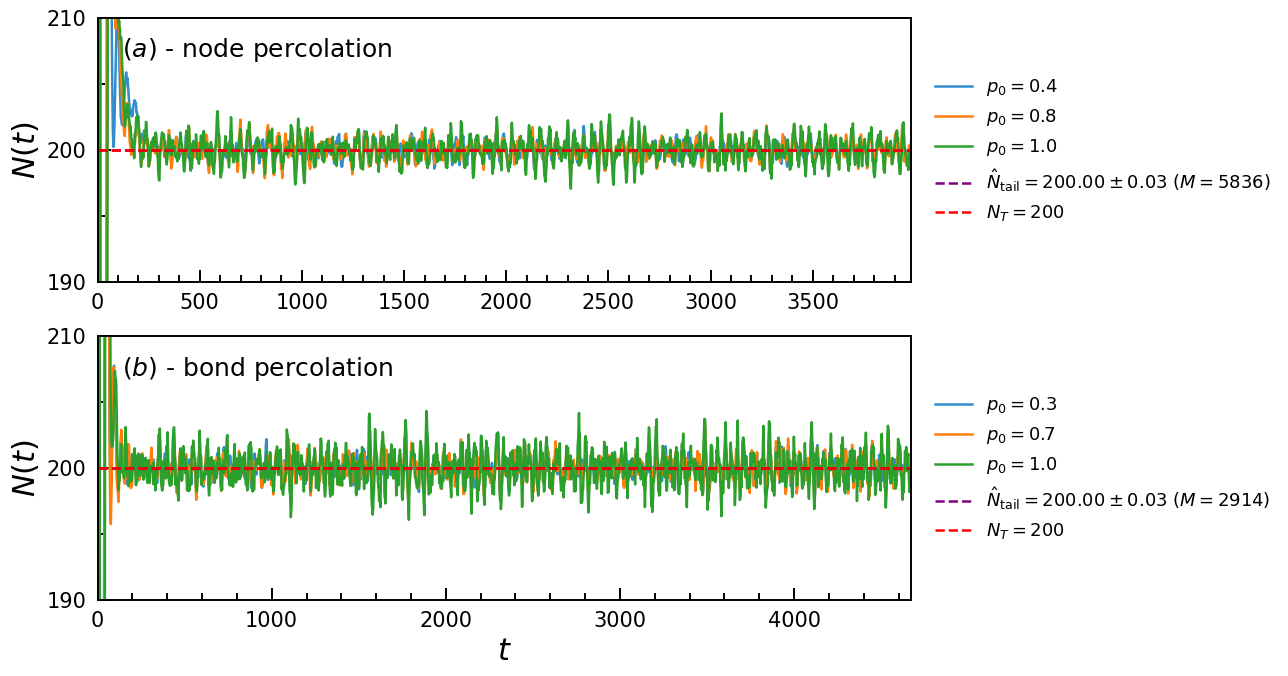

In [5]:
# parâmetros
L = 2000
NT = 200
k  = 1.0e-04
num_colors = 1
rho = 1.0
dim = 2

p0_list_node = [0.4, 0.8, 1.0]
p0_list_bond = [0.3, 0.7, 1.0]
burn = 300

# leia do bundle + counts
p_node, N_node, C_node = mean_properties_bundle('node', num_colors, dim, L, NT, k, rho, p0_list_node, with_counts=True)
p_bond, N_bond, C_bond = mean_properties_bundle('bond', num_colors, dim, L, NT, k, rho, p0_list_bond, with_counts=True)

# figura
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(13, 7), sharex=False)
colors = ["#318dce", '#ff7f0e', '#2ca02c', '#d62728']
fontsize_ticks = 15; fontsize_legend = 13; fontsize_labels = 22; thickness = 1.4
color_pc = "purple"

def max_t(stats_by_p0):
    vals = [np.max(d["t_grid"]) for d in stats_by_p0.values() if d["t_grid"].size]
    return float(np.max(vals)) if vals else 4000.0

# ===== NODE: N(t) =====
xmax_node = max_t(N_node)
per_p0_est = []  # (mean, se, runs)
for i, p0 in enumerate(p0_list_node):
    d = N_node[p0]
    if d["t_grid"].size == 0: 
        continue
    axs[0].plot(d["t_grid"], d["mean"], color=colors[i%len(colors)], lw=1.8, label=rf'$p_0={p0}$')
    m_w, se_w, *_ = weighted_tail_from_sem(d, t_from=burn, corr_correct=True)
    per_p0_est.append((m_w, se_w, C_node[p0]["runs_N"]))

# combine por inversa da variância
if per_p0_est:
    ws  = np.array([1/s**2 for _, s, _ in per_p0_est if np.isfinite(s) and s>0])
    mus = np.array([m       for m, s, _ in per_p0_est if np.isfinite(s) and s>0])
    Msum = int(np.sum([r for _, s, r in per_p0_est if np.isfinite(s) and s>0]))
    if ws.size:
        mu = float(np.sum(ws*mus)/np.sum(ws))
        se = float(1/np.sqrt(np.sum(ws)))
        axs[0].axhline(mu, 0, 1, color=color_pc, ls='--', lw=1.8,
                       label=rf'$\hat N_{{\rm tail}} = {mu:.2f} \pm {se:.2f}\ (M={Msum})$')

axs[0].axhline(NT, 0, 1, color='r', ls='--', lw=1.8, label=rf'$N_T={NT}$')
axs[0].set_xlim(0, xmax_node)
axs[0].set_ylim(190, 210)
axs[0].set_ylabel(r"$N(t)$", fontsize=fontsize_labels)
axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes, ha="left", va="top", fontsize=18)

# ===== BOND: N(t) =====
xmax_bond = max_t(N_bond)
per_p0_est = []
for i, p0 in enumerate(p0_list_bond):
    d = N_bond[p0]
    if d["t_grid"].size == 0: 
        continue
    axs[1].plot(d["t_grid"], d["mean"], color=colors[i%len(colors)], lw=1.8, label=rf'$p_0={p0}$')
    m_w, se_w, *_ = weighted_tail_from_sem(d, t_from=burn, corr_correct=True)
    per_p0_est.append((m_w, se_w, C_bond[p0]["runs_N"]))

if per_p0_est:
    ws  = np.array([1/s**2 for _, s, _ in per_p0_est if np.isfinite(s) and s>0])
    mus = np.array([m       for m, s, _ in per_p0_est if np.isfinite(s) and s>0])
    Msum = int(np.sum([r for _, s, r in per_p0_est if np.isfinite(s) and s>0]))
    if ws.size:
        mu = float(np.sum(ws*mus)/np.sum(ws))
        se = float(1/np.sqrt(np.sum(ws)))
        axs[1].axhline(mu, 0, 1, color=color_pc, ls='--', lw=1.8,
                       label=rf'$\hat N_{{\rm tail}} = {mu:.2f} \pm {se:.2f}\ (M={Msum})$')

axs[1].axhline(NT, 0, 1, color='r', ls='--', lw=1.8, label=rf'$N_T={NT}$')
axs[1].set_xlim(0, xmax_bond)
axs[1].set_ylim(190, 210)
axs[1].set_xlabel("$t$", fontsize=fontsize_labels)
axs[1].set_ylabel(r"$N(t)$", fontsize=fontsize_labels)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes, ha="left", va="top", fontsize=18)

# estilo comum
for ax in axs:
    for spine in ax.spines.values(): spine.set_linewidth(thickness)
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))
    ax.tick_params(axis='both', which='major', direction='in', length=9, width=thickness, pad=8)
    ax.tick_params(axis='x', which='minor', direction='in', length=5, width=thickness)
    ax.tick_params(axis='y', which='minor', direction='in', length=5, width=thickness)
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), framealpha=0.0, fontsize=fontsize_legend)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

NameError: name 'p_node' is not defined

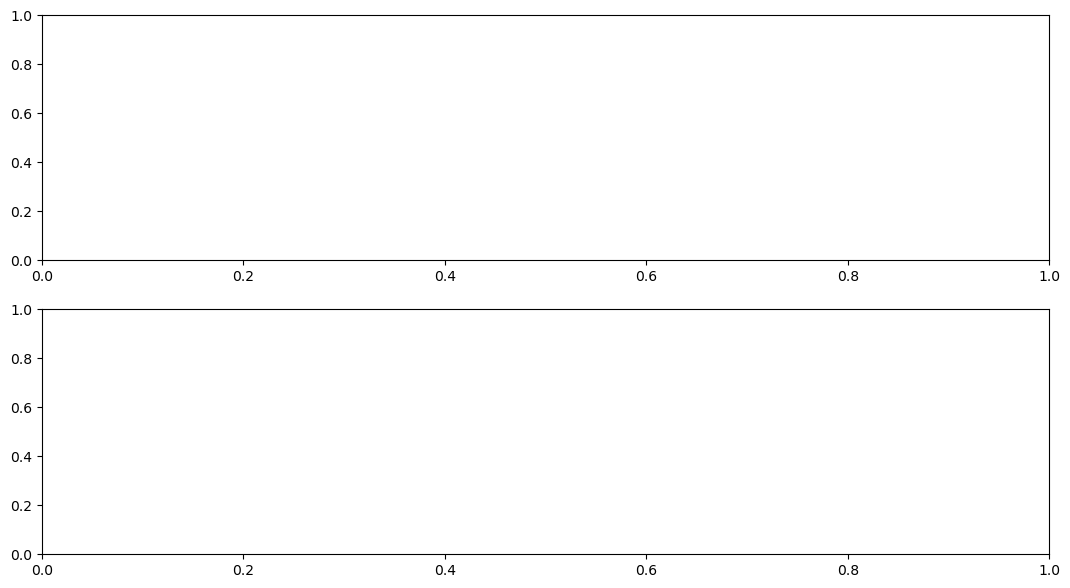

In [4]:
# ===== p(t): node (top) & bond (bottom) =====

burn = 300
colors = ["#318dce", '#ff7f0e', '#2ca02c', '#d62728']
fontsize_ticks = 15; fontsize_legend = 13; fontsize_labels = 22; thickness = 1.4
color_pc = "purple"

def max_t(stats_by_p0):
    vals = [np.max(d["t_grid"]) for d in stats_by_p0.values() if d["t_grid"].size]
    return float(np.max(vals)) if vals else 4000.0

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(13, 7), sharex=False)

# -------- (a) NODE: p(t) --------
xmax_node = max_t(p_node)
per_p0_est = []  # (mean, se, runs)
for i, p0 in enumerate(p0_list_node):
    d = p_node[p0]
    if d["t_grid"].size == 0:
        continue
    axs[0].plot(d["t_grid"], d["mean"],
                color=colors[i % len(colors)], lw=1.8, label=rf'$p_0={p0}$')
    m_w, se_w, *_ = weighted_tail_from_sem(d, t_from=burn, corr_correct=True)
    per_p0_est.append((m_w, se_w, C_node[p0]["runs_p"]))

# combinar por inversa da variância
if per_p0_est:
    ws  = np.array([1/s**2 for _, s, _ in per_p0_est if np.isfinite(s) and s>0])
    mus = np.array([m       for m, s, _ in per_p0_est if np.isfinite(s) and s>0])
    Msum = int(np.sum([r for _, s, r in per_p0_est if np.isfinite(s) and s>0]))
    if ws.size:
        mu = float(np.sum(ws*mus)/np.sum(ws))
        se = float(1/np.sqrt(np.sum(ws)))
        axs[0].axhline(mu, 0, 1, color=color_pc, ls='--', lw=1.8,
                       label=rf'$ \hat p_{{\rm tail}} = {mu:.5f} \pm {se:.5f}\ (M={Msum})$')

# referência p_c (site / node em rede quadrada 2D)
pc_site = 0.59274
axs[0].axhline(pc_site, 0, 1, color='r', ls='--', lw=1.8,
               label=rf'$p_c = {pc_site}$')

axs[0].set_xlim(0, xmax_node)
axs[0].set_ylim(0.55, 0.65)   # ajuste fino se quiser
axs[0].set_ylabel(r"$p(t)$", fontsize=fontsize_labels)
axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes,
            ha="left", va="top", fontsize=18)

# -------- (b) BOND: p(t) --------
xmax_bond = max_t(p_bond)
per_p0_est = []
for i, p0 in enumerate(p0_list_bond):
    d = p_bond[p0]
    if d["t_grid"].size == 0:
        continue
    axs[1].plot(d["t_grid"], d["mean"],
                color=colors[i % len(colors)], lw=1.8, label=rf'$p_0={p0}$')
    m_w, se_w, *_ = weighted_tail_from_sem(d, t_from=burn, corr_correct=True)
    per_p0_est.append((m_w, se_w, C_bond[p0]["runs_p"]))

if per_p0_est:
    ws  = np.array([1/s**2 for _, s, _ in per_p0_est if np.isfinite(s) and s>0])
    mus = np.array([m       for m, s, _ in per_p0_est if np.isfinite(s) and s>0])
    Msum = int(np.sum([r for _, s, r in per_p0_est if np.isfinite(s) and s>0]))
    if ws.size:
        mu = float(np.sum(ws*mus)/np.sum(ws))
        se = float(1/np.sqrt(np.sum(ws)))
        axs[1].axhline(mu, 0, 1, color=color_pc, ls='--', lw=1.8,
                       label=rf'$ \hat p_{{\rm tail}} = {mu:.5f} \pm {se:.5f}\ (M={Msum})$')

# referência p_c (bond em rede quadrada 2D)
pc_bond = 0.50
axs[1].axhline(pc_bond, 0, 1, color='r', ls='--', lw=1.8,
               label=rf'$p_c = {pc_bond}$')

axs[1].set_xlim(0, xmax_bond)
axs[1].set_ylim(0.45, 0.55)   # ajuste fino se quiser
axs[1].set_xlabel("$t$", fontsize=fontsize_labels)
axs[1].set_ylabel(r"$p(t)$", fontsize=fontsize_labels)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes,
            ha="left", va="top", fontsize=18)

# ---- estilo comum ----
for ax in axs:
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_major_locator(MultipleLocator(0.02))
    ax.yaxis.set_minor_locator(MultipleLocator(0.005))
    ax.tick_params(axis='both', which='major', direction='in',
                   length=9, width=thickness, pad=8)
    ax.tick_params(axis='x', which='minor', direction='in', length=5, width=thickness)
    ax.tick_params(axis='y', which='minor', direction='in', length=5, width=thickness)
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
              framealpha=0.0, fontsize=fontsize_legend)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [ ]:
# --- parâmetros do experimento ---
L = 2000
NT = 200
k_list  = [1.0e-04, 1.0e-05, 1.0e-06]
num_colors = 1 
rho = 1.0
dim = 2
type_perc = 'bond'

# --- estilo/figura ---
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(13, 5), sharex=False)
colors = ["#318dce", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
fontsize_legend = 12
fontsize_labels = 18
thickness = 1.4

p0 = 1.0
color_pc = "purple"
xmax = 4000
burn = 300  # burn-in para o platô

# ============== ESQUERDA: p(t) para cada k =================
p_runs_all = []   # guarda médias no platô por run (para todos os k)

for i, k in enumerate(k_list):
    data_p, data_n = mean_properties(type_perc, num_colors, dim, L, NT, k, rho, p0)

    # curva média no tempo (visual)
    axs[0].plot(
        data_p["t_grid"], data_p["mean"], color=colors[i],
        label=rf'$k={k:.1e}$', lw=1.8
    )

    # estimador entre runs (RECOMENDADO) para p(t) no platô
    m_runs_p = tail_mean_per_run(data_p, t_from=burn)
    if m_runs_p.size:
        p_runs_all.append(m_runs_p)

# combina entre runs (todas execs de todos os k) para p
if p_runs_all:
    p_runs_concat = np.concatenate(p_runs_all)
    p_tail_mean, p_tail_se, Mp = mean_and_se_across_runs(p_runs_concat)
else:
    p_tail_mean, p_tail_se, Mp = np.nan, np.nan, 0

axs[0].axhline(
    y=p_tail_mean, xmin=0, xmax=1,
    label=rf'$\overline{{p}}_{{\rm tail}} = {p_tail_mean:.3f} \pm {p_tail_se:.3f}\ (M={Mp})$',
    color=color_pc, lw=1.8, ls="--"
)

# formato painel p(t)
axs[0].set_xlim(0, xmax)
axs[0].set_ylabel(r"$p(t)$", fontsize=fontsize_labels)
axs[0].set_xlabel(r"$t$", fontsize=fontsize_labels)
axs[0].tick_params(axis='both', labelsize=fontsize_ticks)
axs[0].legend(loc='upper right', framealpha=0.0, fontsize=fontsize_legend)
#axs[0].yaxis.set_major_locator(MultipleLocator(0.02))
#axs[0].yaxis.set_minor_locator(MultipleLocator(0.005))

# ============== DIREITA: N(t) para cada k =================
N_runs_all = []  # médias no platô por run (para todos os k)

for i, k in enumerate(k_list):
    data_p, data_n = mean_properties(type_perc, num_colors, dim, L, NT, k, rho, p0)

    axs[1].plot(
        data_n["t_grid"], data_n["mean"], color=colors[i],
        label=rf'$k={k:.1e}$', lw=1.8
    )

    # estimador entre runs (RECOMENDADO) para N(t) no platô
    m_runs_n = tail_mean_per_run(data_n, t_from=burn)
    if m_runs_n.size:
        N_runs_all.append(m_runs_n)

# combina entre runs (todas execs de todos os k) para N
if N_runs_all:
    N_runs_concat = np.concatenate(N_runs_all)
    N_tail_mean, N_tail_se, MN = mean_and_se_across_runs(N_runs_concat)
else:
    N_tail_mean, N_tail_se, MN = np.nan, np.nan, 0

axs[1].axhline(
    y=N_tail_mean, xmin=0, xmax=1,
    label=rf'$\overline{{N}}_{{\rm tail}} = {N_tail_mean:.2f} \pm {N_tail_se:.2f}\ (M={MN})$',
    color=color_pc, lw=1.8, ls="--"
)
axs[1].axhline(
    y=NT, xmin=0, xmax=1, color='r', ls='--', lw=1.8, label=rf'$N_T={NT}$'
)

# formato painel N(t)
axs[1].set_xlim(0, xmax)
axs[1].set_ylabel(r"$N(t)$", fontsize=fontsize_labels)
axs[1].set_xlabel(r"$t$", fontsize=fontsize_labels)
axs[1].tick_params(axis='both', labelsize=fontsize_ticks)
axs[1].legend(loc='upper right', framealpha=0.0, fontsize=fontsize_legend)
#axs[1].yaxis.set_major_locator(MultipleLocator(10))
#axs[1].yaxis.set_minor_locator(MultipleLocator(5))

# estética comum
for ax in axs:
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    ax.tick_params(axis='both', which='major', direction='in',
                   length=9, width=thickness, pad=6)
    ax.tick_params(axis='x', which='minor', direction='in',
                   length=5, width=thickness)
    ax.tick_params(axis='y', which='minor', direction='in',
                   length=5, width=thickness)
    ax.xaxis.set_minor_locator(AutoMinorLocator())

fig.tight_layout()
axs[0].set_ylim(0.48, 0.52)
axs[1].set_ylim(0, 250)
# plt.savefig("k_effects_p_and_N.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# --- parâmetros do experimento ---
L = 2000
NT_list = [200, 300, 400]   # vamos variar NT
k = 1.0e-05                 # k fixo (você tinha "k_list = 1e-5"; aqui é só k)
num_colors = 1 
rho = 1.0
dim = 2
type_perc = 'bond'
p0 = 1.0

# --- estilo/figura ---
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(13, 5), sharex=False)
colors = ["#318dce", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
fontsize_legend = 12
fontsize_labels = 18
thickness = 1.4

color_pc = "purple"
xmax = 4000
burn = 300  # burn-in para o platô

# ============== ESQUERDA: p(t) variando NT =================
p_runs_all = []   # médias no platô por run (todas as NT)

for i, NT in enumerate(NT_list):
    data_p, data_n = mean_properties(type_perc, num_colors, dim, L, NT, k, rho, p0)

    # curva média no tempo (visual)
    axs[0].plot(
        data_p["t_grid"], data_p["mean"], color=colors[i % len(colors)],
        label=rf'$N_T={NT}$', lw=1.8
    )

    # estimador entre runs (RECOMENDADO) para p(t) no platô
    m_runs_p = tail_mean_per_run(data_p, t_from=burn)
    if m_runs_p.size:
        p_runs_all.append(m_runs_p)

# combina entre runs (todas execuções de todos os NT) para p
if p_runs_all:
    p_runs_concat = np.concatenate(p_runs_all)
    p_tail_mean, p_tail_se, Mp = mean_and_se_across_runs(p_runs_concat)
else:
    p_tail_mean, p_tail_se, Mp = np.nan, np.nan, 0

axs[0].axhline(
    y=p_tail_mean, xmin=0, xmax=1,
    label=rf'$\overline{{p}}_{{\rm tail}} = {p_tail_mean:.3f} \pm {p_tail_se:.3f}\ (M={Mp})$',
    color=color_pc, lw=1.8, ls="--"
)

# formato painel p(t)
axs[0].set_xlim(0, xmax)
axs[0].set_ylabel(r"$p(t)$", fontsize=fontsize_labels)
axs[0].set_xlabel(r"$t$", fontsize=fontsize_labels)
axs[0].tick_params(axis='both', labelsize=fontsize_ticks)
axs[0].legend(loc='upper right', framealpha=0.0, fontsize=fontsize_legend)
# opcional: ajuste dos ticks de p(t)
# from matplotlib.ticker import MultipleLocator
# axs[0].yaxis.set_major_locator(MultipleLocator(0.02))
# axs[0].yaxis.set_minor_locator(MultipleLocator(0.005))

# ============== DIREITA: N(t) variando NT =================
N_runs_all = []  # médias no platô por run (todas as NT)

for i, NT in enumerate(NT_list):
    data_p, data_n = mean_properties(type_perc, num_colors, dim, L, NT, k, rho, p0)

    axs[1].plot(
        data_n["t_grid"], data_n["mean"], color=colors[i % len(colors)],
        label=rf'$N_T={NT}$', lw=1.8
    )

    # estimador entre runs (RECOMENDADO) para N(t) no platô
    m_runs_n = tail_mean_per_run(data_n, t_from=burn)
    if m_runs_n.size:
        N_runs_all.append(m_runs_n)

    # linha-alvo N_T da PRÓPRIA curva (mesma cor)
    axs[1].axhline(y=NT, xmin=0, xmax=1, color=colors[i % len(colors)],
                   ls=':', lw=1.4)

# combina entre runs (todas execuções de todos os NT) para N
if N_runs_all:
    N_runs_concat = np.concatenate(N_runs_all)
    N_tail_mean, N_tail_se, MN = mean_and_se_across_runs(N_runs_concat)
else:
    N_tail_mean, N_tail_se, MN = np.nan, np.nan, 0

axs[1].axhline(
    y=N_tail_mean, xmin=0, xmax=1,
    label=rf'$\overline{{N}}_{{\rm tail}} = {N_tail_mean:.1f} \pm {N_tail_se:.1f}\ (M={MN})$',
    color=color_pc, lw=1.8, ls="--"
)

# formato painel N(t)
axs[1].set_xlim(0, xmax)
axs[1].set_ylabel(r"$N(t)$", fontsize=fontsize_labels)
axs[1].set_xlabel(r"$t$", fontsize=fontsize_labels)
axs[1].tick_params(axis='both', labelsize=fontsize_ticks)
axs[1].legend(loc='upper right', framealpha=0.0, fontsize=fontsize_legend)

# estética comum
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
for ax in axs:
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    ax.tick_params(axis='both', which='major', direction='in',
                   length=9, width=thickness, pad=6)
    ax.tick_params(axis='x', which='minor', direction='in',
                   length=5, width=thickness)
    ax.tick_params(axis='y', which='minor', direction='in',
                   length=5, width=thickness)
    ax.xaxis.set_minor_locator(AutoMinorLocator())

# limites (ajuste conforme seus dados)
axs[0].set_xlim(0, xmax)
axs[1].set_xlim(0, xmax)
axs[1].set_ylim(0, max(NT_list) + 100)  # ex.: até 500 para NT=400
axs[0].set_ylim(0.475, 0.525)
fig.tight_layout()
# plt.savefig("NT_effects_p_and_N.pdf", bbox_inches="tight")
plt.show()


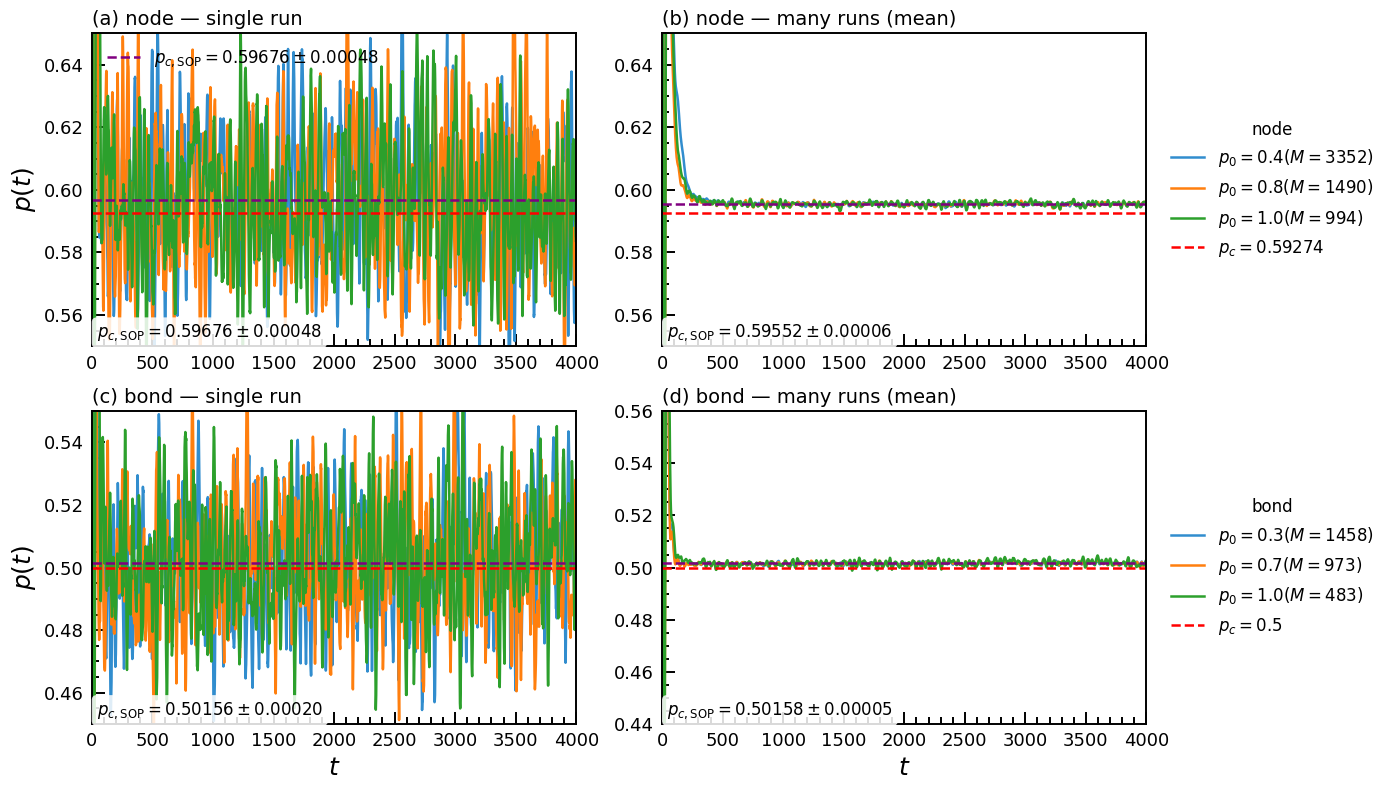

O número de amostras afeta de forma muito sútil o p_médio


In [45]:
# ----- params -----
L = 2000; NT = 200; k = 1.0e-04
num_colors = 1; rho = 1.0; dim = 2; burn = 300
p0_node = [0.4, 0.8, 1.0]
p0_bond = [0.3, 0.7, 1.0]
seeds_node = [703521993, 1892779238, 1268506543]
seeds_bond = [24139811, 363075982, 974692235]
pc_node, pc_bond = 0.59274, 0.50

# bundle (múltiplas amostras)
p_node, N_node, C_node = mean_properties_bundle('node', num_colors, dim, L, NT, k, rho, p0_node, with_counts=True)
p_bond, N_bond, C_bond = mean_properties_bundle('bond', num_colors, dim, L, NT, k, rho, p0_bond, with_counts=True)

# ----- estilo -----
colors = ["#318dce", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13; fontsize_legend = 12; fontsize_labels = 18; thickness = 1.4
tail_color = "purple"
legend_box = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, linewidth=0)

def _max_t(stats_by_p0):
    vals = [np.max(d["t_grid"]) for d in stats_by_p0.values() if d["t_grid"].size]
    return float(np.max(vals)) if vals else 4000.0

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

# ================= Row 1: NODE =================
# (0,0) node — single run
ax = axs[0,0]
tails = []
for i, (p0, seed) in enumerate(zip(p0_node, seeds_node)):
    d = data_single_sample('node', num_colors, dim, L, NT, k, rho, p0, seed)
    t = np.asarray(d["t"], float); p = np.asarray(d["p_1"], float)
    ax.plot(t, p, color=colors[i%len(colors)], lw=1.8, label="_nolegend_")
    if np.any(t >= burn): tails.append(np.mean(p[t >= burn]))
# p_tail legend inside
if len(tails):
    mu = float(np.mean(tails))
    se = float(np.std(tails, ddof=1)/np.sqrt(len(tails))) if len(tails)>1 else 0.0
    h = ax.axhline(mu, 0, 1, color=tail_color, ls="--", lw=1.8,
                   label=rf'$p_{{c,\mathrm{{SOP}}}} = {mu:.5f} \pm {se:.5f}$')
    ax.legend(handles=[h], loc="upper left", frameon=False, fontsize=fontsize_legend,
              title=None, labelspacing=0.4)
    ax.text(0.01, 0.03, h.get_label(), transform=ax.transAxes,
            fontsize=fontsize_legend, bbox=legend_box)
ax.axhline(pc_node, 0, 1, color="r", ls="--", lw=1.8)
ax.set_title(r"(a) node — single run", loc="left", fontsize=14)
ax.set_ylabel(r"$p(t)$", fontsize=fontsize_labels)

# (0,1) node — many runs (mean)
ax = axs[0,1]
row_handles, row_labels = [], []
for i, p0 in enumerate(p0_node):
    d = p_node[p0]
    files_used = C_node[p0]['files_used']
    if d["t_grid"].size == 0: continue
    ln, = ax.plot(d["t_grid"], d["mean"], color=colors[i%len(colors)], lw=1.8, label=rf'$p_0={p0}, M = {files_used}')
    row_handles.append(ln); row_labels.append(rf'$p_0={p0} (M = {files_used})$')
# p_tail legend inside (weighted + combinado nos p0)
tails_w = []
for p0 in p0_node:
    d = p_node[p0]
    if d["t_grid"].size == 0: continue
    mu, se, *_ = weighted_tail_from_sem(d, t_from=burn, corr_correct=True)
    tails_w.append((mu, se))
if tails_w:
    ws  = np.array([1/s**2 for m,s in tails_w if np.isfinite(s) and s>0])
    mus = np.array([m       for m,s in tails_w if np.isfinite(s) and s>0])
    if ws.size:
        mu = float(np.sum(ws*mus)/np.sum(ws)); se = float(1/np.sqrt(np.sum(ws)))
        h = ax.axhline(mu, 0, 1, color=tail_color, ls="--", lw=1.8,
                       label=rf'$p_{{c,\mathrm{{SOP}}}} = {mu:.5f} \pm {se:.5f}$')
        ax.text(0.01, 0.03, h.get_label(), transform=ax.transAxes,
                fontsize=fontsize_legend, bbox=legend_box)

pc_line = ax.axhline(pc_node, 0, 1, color="r", ls="--", lw=1.8, label=rf"$p_c = {pc_node}$")
row_handles.append(pc_line); row_labels.append(rf"$p_c = {pc_node}$")
ax.set_title(r"(b) node — many runs (mean)", loc="left", fontsize=14)
#ax.set_ylabel(r"$p(t)$", fontsize=fontsize_labels)
ax.set_xlim(0,4000)
# legenda comum da 1ª linha (à direita)
axs[0,1].legend(row_handles, row_labels, loc="center left",
                bbox_to_anchor=(1.02, 0.5), framealpha=0.0, fontsize=fontsize_legend).set_title("node", prop={'size': fontsize_legend})

# ==== y-range IGUAL para os dois painéis da 1ª linha ====
for ax in axs[0,:]:
    ax.set_ylim(0.55, 0.65)   # escolha comum
    ax.set_xlim(0, _max_t(p_node))

# ================= Row 2: BOND =================
# (1,0) bond — single run
ax = axs[1,0]
tails = []
for i, (p0, seed) in enumerate(zip(p0_bond, seeds_bond)):
    d = data_single_sample('bond', num_colors, dim, L, NT, k, rho, p0, seed)
    t = np.asarray(d["t"], float); p = np.asarray(d["p_1"], float)
    ax.plot(t, p, color=colors[i%len(colors)], lw=1.8, label="_nolegend_")
    if np.any(t>=burn): tails.append(np.mean(p[t>=burn]))
if len(tails):
    mu = float(np.mean(tails))
    se = float(np.std(tails, ddof=1)/np.sqrt(len(tails))) if len(tails)>1 else 0.0
    h = ax.axhline(mu, 0, 1, color=tail_color, ls="--", lw=1.8,
                   label=rf'$p_{{c,\mathrm{{SOP}}}} = {mu:.5f} \pm {se:.5f}$')
    ax.text(0.01, 0.03, h.get_label(), transform=ax.transAxes,
            fontsize=fontsize_legend, bbox=legend_box)

ax.axhline(pc_bond, 0, 1, color="r", ls="--", lw=1.8)
ax.set_title(r"(c) bond — single run", loc="left", fontsize=14)
axs[0,0].set_ylabel(r"$p(t)$", fontsize=fontsize_labels)
ax.set_ylim(0.45, 0.55); ax.set_xlim(0, np.max(t) if 't' in locals() and t.size else 4000)

# (1,1) bond — many runs (mean)
ax = axs[1,1]
row_handles, row_labels = [], []
for i, p0 in enumerate(p0_bond):
    d = p_bond[p0]
    files_used = C_bond[p0]['files_used']
    if d["t_grid"].size == 0: continue
    ln, = ax.plot(d["t_grid"], d["mean"], color=colors[i%len(colors)], lw=1.8, label=rf'$p_0={p0} (M = {files_used})$')
    row_handles.append(ln); row_labels.append(rf'$p_0={p0} (M = {files_used})$')
# p_tail inside
tails_w = []
for p0 in p0_bond:
    d = p_bond[p0]
    if d["t_grid"].size == 0: continue
    mu, se, *_ = weighted_tail_from_sem(d, t_from=burn, corr_correct=True)
    tails_w.append((mu, se))
if tails_w:
    ws  = np.array([1/s**2 for m,s in tails_w if np.isfinite(s) and s>0])
    mus = np.array([m       for m,s in tails_w if np.isfinite(s) and s>0])
    if ws.size:
        mu = float(np.sum(ws*mus)/np.sum(ws)); se = float(1/np.sqrt(np.sum(ws)))
        h = ax.axhline(mu, 0, 1, color=tail_color, ls="--", lw=1.8,
                       label=rf'$p_{{c,\mathrm{{SOP}}}} = {mu:.5f} \pm {se:.5f}$')
        ax.text(0.01, 0.03, h.get_label(), transform=ax.transAxes,
                fontsize=fontsize_legend, bbox=legend_box)

pc_line = ax.axhline(pc_bond, 0, 1, color="r", ls="--", lw=1.8, label=rf"$p_c = {pc_bond}$")
row_handles.append(pc_line); row_labels.append(rf"$p_c = {pc_bond}$")
ax.set_title(r"(d) bond — many runs (mean)", loc="left", fontsize=14)
axs[1,0].set_ylabel(r"$p(t)$", fontsize=fontsize_labels)
ax.set_ylim(0.44, 0.56)


# legenda comum da 2ª linha
axs[1,1].legend(row_handles, row_labels, loc="center left",
                bbox_to_anchor=(1.02, 0.5), framealpha=0.0, fontsize=fontsize_legend).set_title("bond", prop={'size': fontsize_legend})

# ----- acabamento comum -----
for ax in axs.ravel():
    for s in ax.spines.values(): s.set_linewidth(thickness)
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_major_locator(MultipleLocator(0.02))
    ax.yaxis.set_minor_locator(MultipleLocator(0.005))
    ax.tick_params(axis='both', which='major', direction='in', length=9, width=thickness, pad=6)
    ax.tick_params(axis='x', which='minor', direction='in', length=5, width=thickness)
    ax.tick_params(axis='y', which='minor', direction='in', length=5, width=thickness)
    ax.set_xlim(0,4000)

axs[1,0].set_xlabel("$t$", fontsize=fontsize_labels)
axs[1,1].set_xlabel("$t$", fontsize=fontsize_labels)
plt.subplots_adjust(wspace=0.35, hspace=0.35)
fig.tight_layout()
plt.show()
print("O número de amostras afeta de forma muito sútil o p_médio")

## 2 COLORS